In [1]:
import pandas as pd
import numpy as np
import sns
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
train = pd.read_csv('data/sign_mnist_train.csv')
test = pd.read_csv('data/sign_mnist_test.csv')

In [3]:
test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7167,1,135,119,108,102,105,99,61,103,121,...,108,112,116,114,118,180,184,176,167,163
7168,12,157,159,161,164,166,166,171,174,175,...,213,213,213,214,213,211,210,210,209,208
7169,2,190,191,190,191,190,190,192,192,191,...,216,215,213,214,214,213,210,211,209,208
7170,4,201,205,208,209,214,216,218,223,226,...,112,169,255,255,237,113,91,67,70,63


In [4]:
train_label = train.iloc[:,:1]
test_label = test.iloc[:,:1]
train_set = train.iloc[:,1:]
test_set = test.iloc[:,1:]

In [5]:
train_set = tf.convert_to_tensor(train_set / 255.0)
test_set = tf.convert_to_tensor(test_set / 255.0)

In [6]:
train_set = tf.reshape(train_set, [-1, 28, 28,1])
test_set = tf.reshape(test_set, [-1, 28, 28,1])

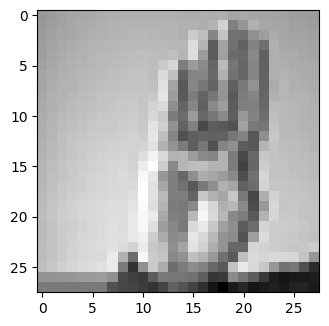

In [7]:
import random
def show_images(image):
    image = image.numpy().reshape(28,28)
    plt.figure(figsize=(8, 8))
    plt.subplot(1,2,2)
    plt.imshow(image, cmap='gray')
show_images(train_set[random.randrange(0,len(train_set))])

In [8]:
train_label = tf.convert_to_tensor(train_label)
test_label = tf.convert_to_tensor(test_label)

In [9]:
train_ds = tf.data.Dataset.from_tensor_slices((train_set, train_label))
test_ds = tf.data.Dataset.from_tensor_slices((test_set, test_label))

In [10]:
final_train_ds, final_val_ds = tf.keras.utils.split_dataset(train_ds, left_size=0.8)

In [11]:
final_train_ds = final_train_ds.shuffle(1000).batch(128)
final_val_ds = final_val_ds.batch(128)

In [12]:
aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [13]:
model = tf.keras.Sequential([])
model.add(tf.keras.Input(shape=(28,28,1)))
model.add(tf.keras.layers.Conv2D(32, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Conv2D(64, (5,5), activation='relu',padding='same'))
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(64, activation='relu'))
model.add(tf.keras.layers.Dense(25, activation='softmax'))

In [14]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         1,625 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 463,513 (1.77 MB)

 Trainable params: 463,513 (1.77 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

In [16]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer=adam_optimizer, metrics=['accuracy'])

In [17]:
history = model.fit(final_train_ds, epochs=10, validation_data=final_val_ds)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.3885 - loss: 1.9697 - val_accuracy: 0.8037 - val_loss: 0.6468
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8278 - loss: 0.5155 - val_accuracy: 0.9718 - val_loss: 0.1406
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9389 - loss: 0.1926 - val_accuracy: 0.9913 - val_loss: 0.0455
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9697 - loss: 0.0990 - val_accuracy: 0.9982 - val_loss: 0.0173
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9855 - loss: 0.0528 - val_accuracy: 0.9976 - val_loss: 0.0088
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.9886 - loss: 0.0396 - val_accuracy: 0.9995 - val_loss: 0.0036
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9910 - loss: 0.0306 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9928 - loss: 0.0244 - val_accu

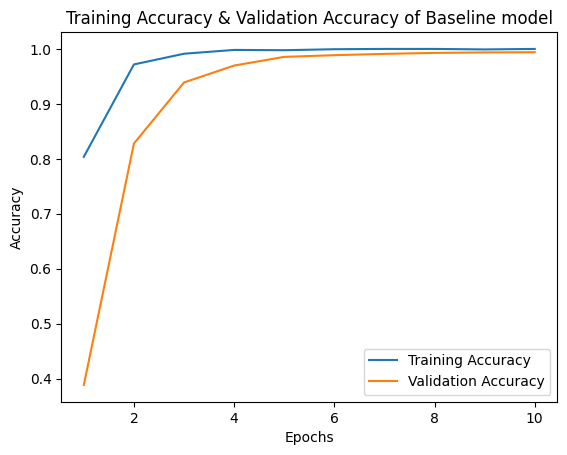

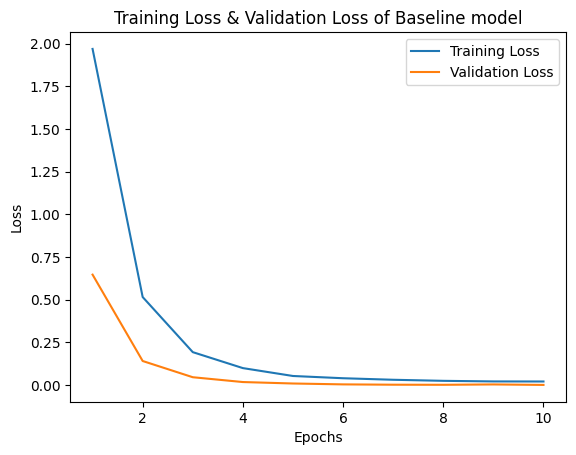

In [18]:
#Reference: https://www.tensorflow.org/tutorials/images/transfer_learning#learning_curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = [1,2,3,4,5,6,7,8,9,10]

plt.plot(epochs, val_acc)
plt.plot(epochs, acc)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy & Validation Accuracy of Baseline model')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

loss = history.history['loss']
val_loss = history.history['val_loss']
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss & Validation Loss of Baseline model')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

In [19]:
prediction = model.predict(test_set)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [20]:
predicted_labels = []
for i in range(0,len(test)):
    predicted_labels.append(np.argmax(prediction[i]))

In [21]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
def plot_confusion_matrix(test_lab, pred_lab):
    cm = confusion_matrix(test_lab,pred_lab)
    alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
    display_cm = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=alphabet)
    #make the Confusion Matrix bigger: https://stackoverflow.com/questions/66483409/adjust-size-of-confusionmatrixdisplay-scikitlearn
    fig, ax = plt.subplots(figsize=(11,11))
    display_cm.plot(ax=ax,cmap="Blues")

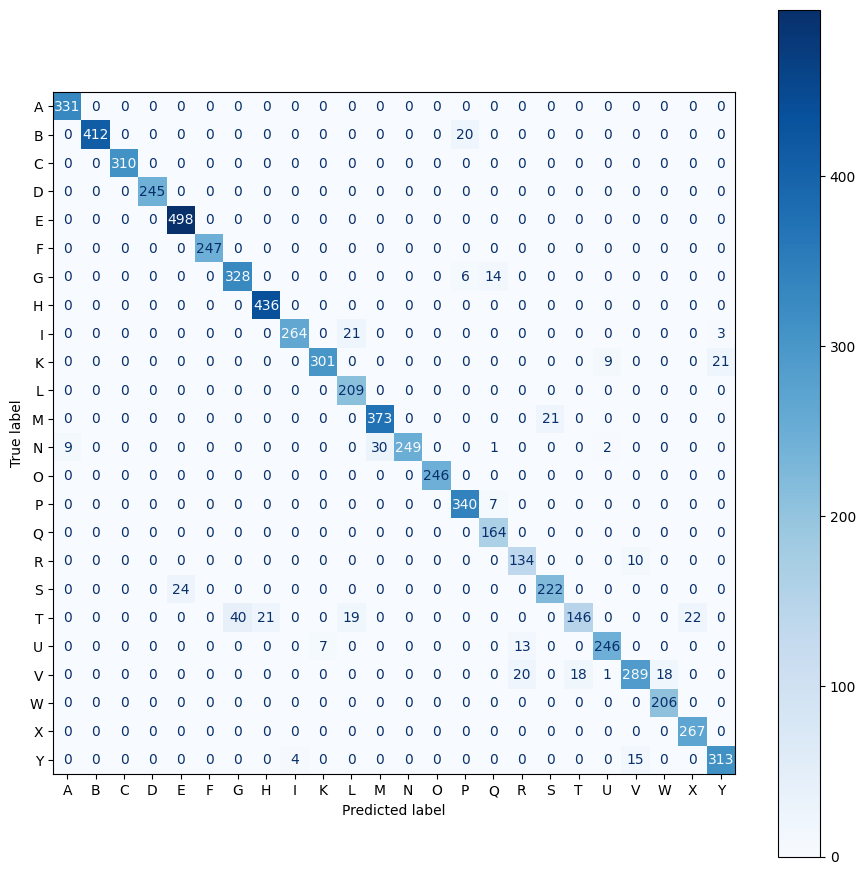

In [22]:
plot_confusion_matrix(test_label,predicted_labels)

In [23]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, classification_report

f1_score = f1_score(test_label,predicted_labels,average='weighted')
accuracy_score = accuracy_score(test_label,predicted_labels)
recall_score = recall_score(test_label,predicted_labels,average='weighted')
precision_score = precision_score(test_label,predicted_labels,average='weighted')

classification_report = classification_report(test_label,predicted_labels)

In [24]:
print("Test Accuracy of the baseline model", accuracy_score)
print("Precision of the baseline model:",precision_score)
print("Recall of the baseline model:", recall_score)
print("F1-score of the baseline model:",f1_score)

Test Accuracy of the baseline model 0.9447852760736196
Precision of the baseline model: 0.9462256599820612
Recall of the baseline model: 0.9447852760736196
F1-score of the baseline model: 0.9433230833541193


In [25]:
def return_alphabet(num):
    alphabet = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']
    if num > 8:
        return alphabet[num-1]
    else:
        return alphabet[num]

True Label: E
Predicted Label: E


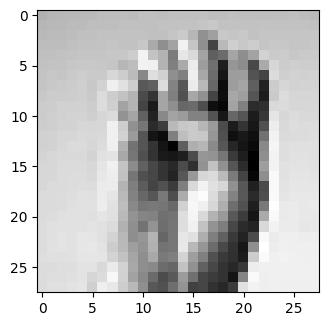

In [58]:
random_number = random.randrange(0,len(test_set))
print("True Label:", return_alphabet(int(test_label[random_number][0])))
print("Predicted Label:", return_alphabet(predicted_labels[random_number]))
show_images(test_set[random_number])

In [27]:
vgg = tf.keras.Sequential([])
vgg.add(tf.keras.Input(shape=(28,28,1)))
#block 1
vgg.add(tf.keras.layers.Conv2D(16, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(16, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(16, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.MaxPooling2D((2,2)))
#block 2
vgg.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.Conv2D(32, (3,3), activation='relu',padding='same'))
vgg.add(tf.keras.layers.MaxPooling2D((2,2)))
#Output
vgg.add(tf.keras.layers.Flatten())
vgg.add(tf.keras.layers.Dense(1024, activation='relu'))
vgg.add(tf.keras.layers.Dropout(0.4))
vgg.add(tf.keras.layers.Dense(512, activation='relu'))
vgg.add(tf.keras.layers.Dropout(0.5))
vgg.add(tf.keras.layers.Dense(25, activation='softmax'))

In [28]:
vgg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1024)           │     1,606,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 25)             │        12,825 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,181,465 (8.32 MB)

 Trainable params: 2,181,465 (8.32 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
vgg.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(), optimizer='adam', metrics=['accuracy'])

In [30]:
vgg_history = vgg.fit(final_train_ds,epochs=10,validation_data=final_val_ds)

Epoch 1/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.4189 - loss: 1.8644 - val_accuracy: 0.9350 - val_loss: 0.2213
Epoch 2/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9336 - loss: 0.1932 - val_accuracy: 0.9938 - val_loss: 0.0174
Epoch 3/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9831 - loss: 0.0507 - val_accuracy: 1.0000 - val_loss: 0.0020
Epoch 4/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9926 - loss: 0.0227 - val_accuracy: 0.9951 - val_loss: 0.0135
Epoch 5/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9921 - loss: 0.0249 - val_accuracy: 0.9989 - val_loss: 0.0017
Epoch 6/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.9941 - loss: 0.0174 - val_accuracy: 0.9982 - val_loss: 0.0073
Epoch 7/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9952 - loss: 0.0154 - val_accuracy: 1.0000 - val_loss: 1.1167e-04
Epoch 8/10
172/172 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.9970 - loss: 0.0092 - val_

In [31]:
vgg_prediction = vgg.predict(test_set)

225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [32]:
vgg_predictions = []
for i in range(0,len(test)):
    vgg_predictions.append(np.argmax(vgg_prediction[i]))

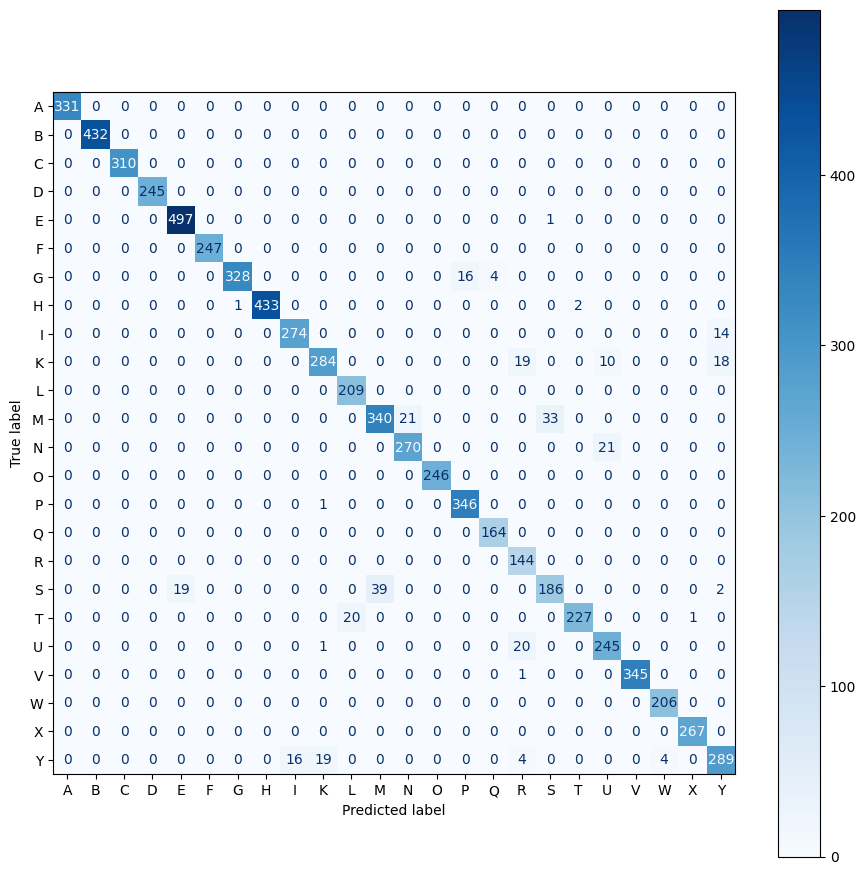

In [33]:
plot_confusion_matrix(test_label,vgg_predictions)

True Label: B
Predicted Label: B


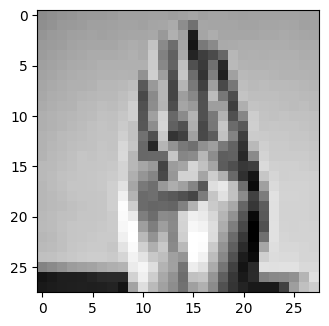

In [99]:
random_number_vgg = random.randrange(0,len(test_set))
print("True Label:", return_alphabet(int(test_label[random_number_vgg][0])))
print("Predicted Label:", return_alphabet(vgg_predictions[random_number_vgg]))
show_images(test_set[random_number_vgg])

In [56]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, classification_report

f1_score_vgg = f1_score(test_label,vgg_predictions,average='weighted')
accuracy_score_vgg = accuracy_score(test_label,vgg_predictions)
recall_score_vgg = recall_score(test_label,vgg_predictions,average='weighted')
precision_score_vgg = precision_score(test_label,vgg_predictions,average='weighted')

classification_report = classification_report(test_label,vgg_predictions)

In [36]:
print("Test Accuracy of VGG-style model:", accuracy_score_vgg)
print("Precision of VGG-style model:",precision_score_vgg)
print("Recall of VGG-style model:", recall_score_vgg)
print("F1-score of VGG-style model:",f1_score_vgg)

Test Accuracy of VGG-style model: 0.9571946458449526
Precision of VGG-style model: 0.9580669443787255
Recall of VGG-style model: 0.9571946458449526
F1-score of VGG-style model: 0.9569301801809603


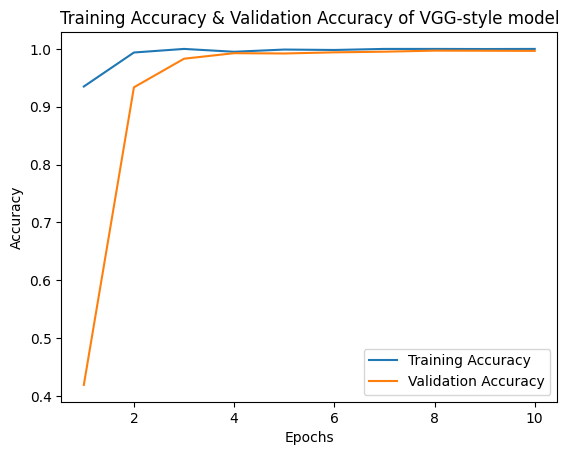

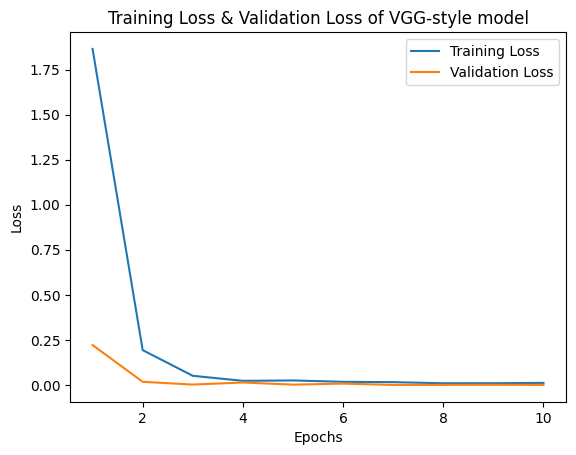

In [37]:
#Reference: https://www.tensorflow.org/tutorials/images/transfer_learning#learning_curves
acc = vgg_history.history['accuracy']
val_acc = vgg_history.history['val_accuracy']
epochs = [1,2,3,4,5,6,7,8,9,10]

plt.plot(epochs, val_acc)
plt.plot(epochs, acc)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Accuracy & Validation Accuracy of VGG-style model')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

loss = vgg_history.history['loss']
val_loss = vgg_history.history['val_loss']
plt.plot(epochs, loss)
plt.plot(epochs, val_loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss & Validation Loss of VGG-style model')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()